In this script, we create an illustration for the calulation of variance and mean for the stochatic damped harmonic oscillator.

In [105]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import scipy
import os
import math
import scipy.linalg
import gaussian_crossings.utils as utils
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process

In [106]:
# Simulation parameters.
T = 20.0                         # Total simulation time.
omega0 = math.sqrt(10.0)                   # Fundamental frequency
zeta = 0.5                      # Damping ratio
temp = 10.0                     # Temperature (similar to sigma ** 2)

if zeta < 1.0:
    dt = 0.001 / (omega0 * max(zeta, math.sqrt(1 - zeta**2)))  
elif zeta == 1.0:
    dt = 0.001 / omega0
else:
    dt = 0.001 / (omega0 * max(zeta + math.sqrt(zeta**2 - 1), zeta - math.sqrt(zeta**2 - 1)))

# define the level u
u = 1.0

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


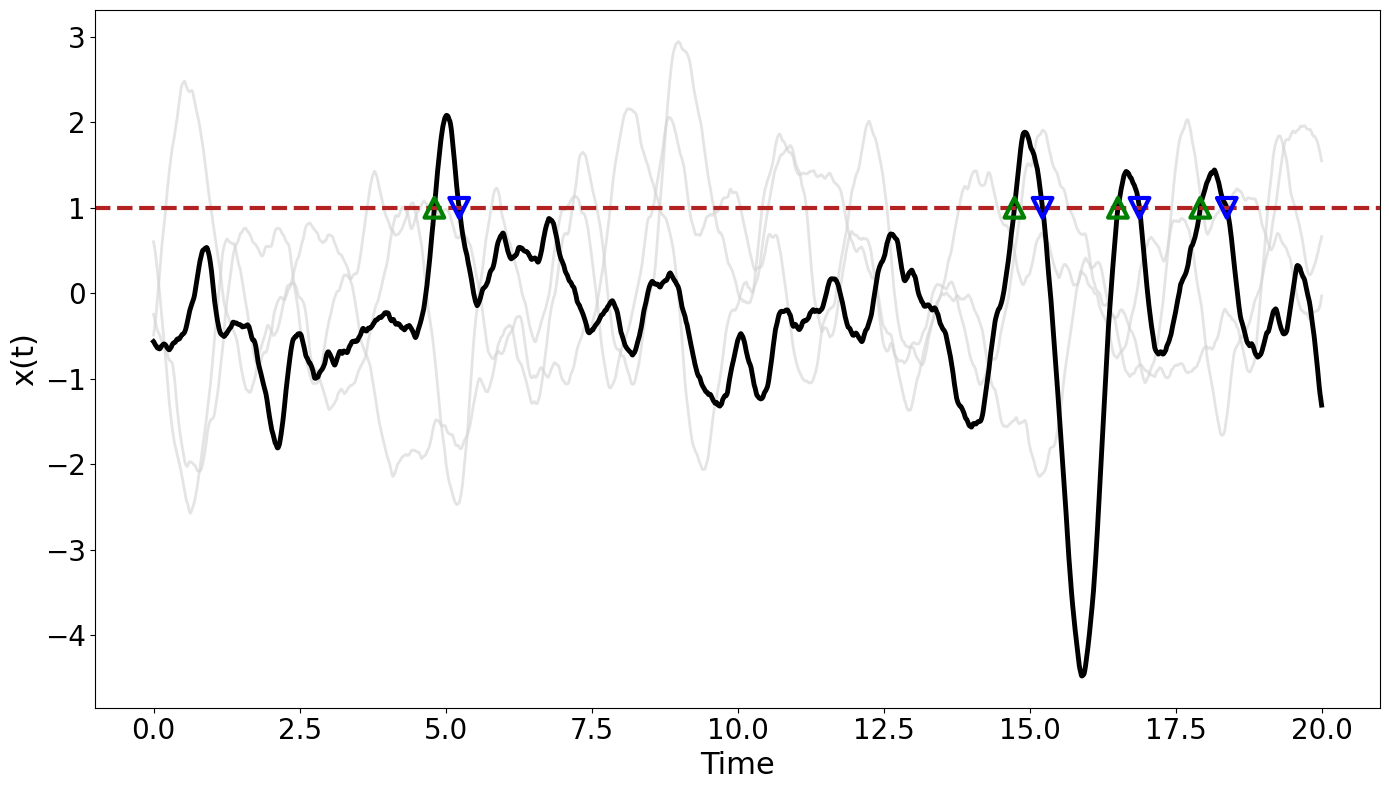

In [107]:
import matplotlib.pyplot as plt
import numpy as np

# Generate 5 background simulations and plot them in gray
plt.figure(figsize=(14, 8))

num_bg_samples = 3
for _ in range(num_bg_samples):
    t, x_bg = utils.simulate_gaussian_process_fft(
        process.r_damped_harmonic_oscillator_noise, T, dt, temp=temp, omega0=omega0, zeta=zeta
    )
    plt.plot(t, x_bg, color='lightgray', alpha=0.6, linewidth=2)

# Main trajectory
t, x = utils.simulate_gaussian_process_fft(
    process.r_damped_harmonic_oscillator_noise, T, dt, temp=temp, omega0=omega0, zeta=zeta
)
times, directions = utils.crossing_times(x, t=t, threshold=u)

# Plot the main trajectory with thicker line
plt.plot(t, x, label='Main sample', color='black', linewidth=3.5)

# Plot the threshold line
plt.axhline(y=u, color='firebrick', linestyle='--', label='Threshold', linewidth=3)

# Upcrossings and downcrossings
up_times = times[directions > 0]
down_times = times[directions < 0]
up_marker_height = u * np.ones_like(up_times)
down_marker_height = u * np.ones_like(down_times)

# Markers
plt.scatter(up_times, up_marker_height, color='green', facecolors='none', edgecolors='green', linewidths=3, marker='^', s=200, label='Upcrossings', zorder=4)
plt.scatter(down_times, down_marker_height, color='blue', facecolors='none', edgecolors='blue', marker='v', linewidths=3, s=200, label='Downcrossings', zorder=4)

# Labels and title with larger fonts
plt.xlabel('Time', fontsize=22)
plt.ylabel('x(t)', fontsize=22)
# plt.title('Gaussian Process with Upcrossings and Downcrossings', fontsize=22)

# Increase tick label font size
plt.tick_params(axis='both', which='major', labelsize=20)

folder_loc = f'../figures/fig1'
os.makedirs(folder_loc, exist_ok=True)
file_name = f'trajectories'
file_save_path = os.path.join(folder_loc, file_name)

plt.savefig(f'{file_save_path}.png', bbox_inches='tight')
plt.savefig(f'{file_save_path}.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.eps', format='eps', bbox_inches='tight', dpi=300)

# Layout
plt.tight_layout()
plt.show()
